# Sales Prediction
**Task 5 - OASIS INFOBYTE Data Science Internship**

Predict product sales based on advertising spend across TV, Radio, and Newspaper channels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
%matplotlib inline

---
## 1. Load the Dataset

In [2]:
df = pd.read_csv('advertising.csv', index_col=0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


---
## 2. Exploratory Data Analysis

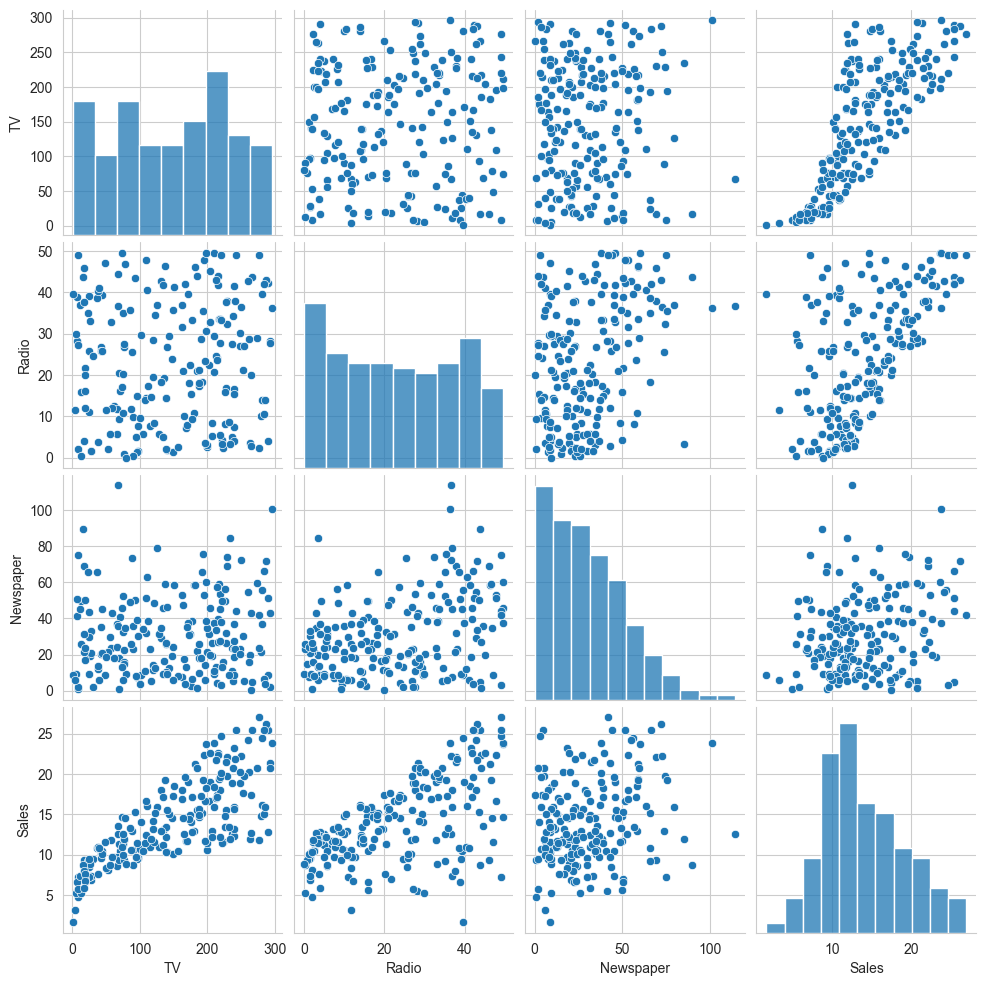

In [5]:
sns.pairplot(df)
plt.show()

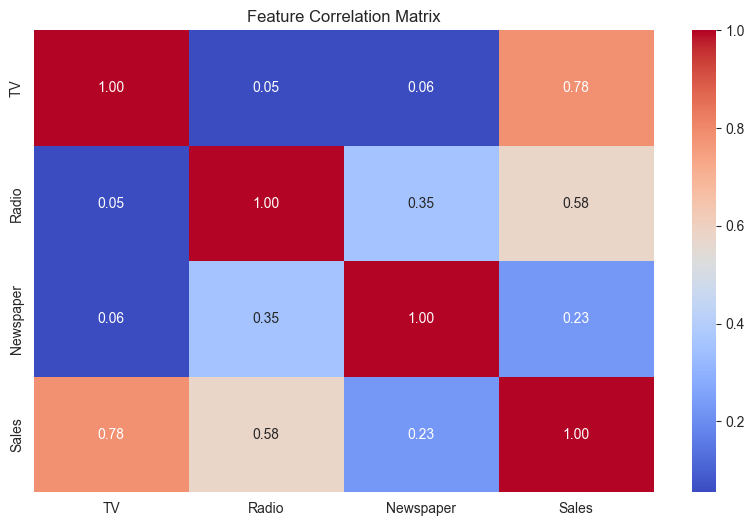

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

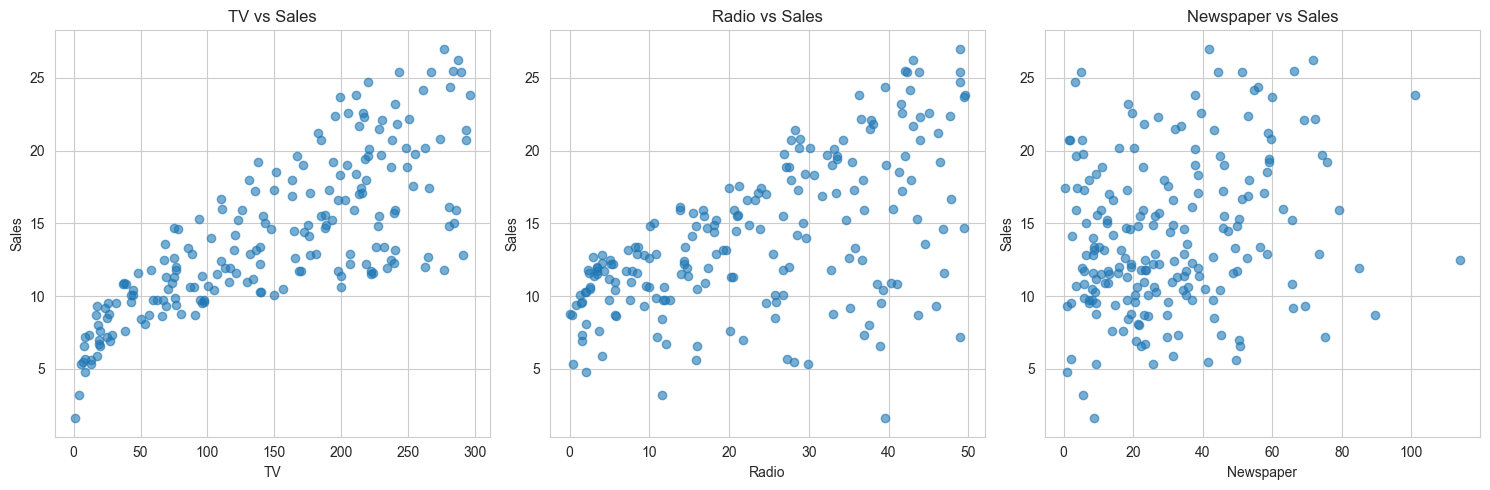

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['TV', 'Radio', 'Newspaper']
for ax, feat in zip(axes, features):
    ax.scatter(df[feat], df['Sales'], alpha=0.6)
    ax.set_xlabel(feat)
    ax.set_ylabel('Sales')
    ax.set_title(f'{feat} vs Sales')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

In [8]:
X = df.drop(columns=['Sales'])
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 160
Test samples: 40


---
## 4. Model Training & Evaluation

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=0.1),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'R2 Score': r2, 'RMSE': rmse, 'MAE': mae}
    
    print(f'\n{"="*40}')
    print(f'{name}')
    print(f'R2 Score: {r2:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')


Linear Regression
R2 Score: 0.8994
RMSE: 1.7816
MAE: 1.4608

Lasso Regression
R2 Score: 0.8983
RMSE: 1.7913
MAE: 1.4613

Ridge Regression
R2 Score: 0.8988
RMSE: 1.7872
MAE: 1.4643

Random Forest
R2 Score: 0.9813
RMSE: 0.7688
MAE: 0.6207


In [10]:
results_df = pd.DataFrame(results).T
results_df

,R2 Score,RMSE,MAE
Linear Regression,0.899438,1.781600,1.460757
Lasso Regression,0.898336,1.791334,1.461273
Ridge Regression,0.898803,1.787220,1.464301
Random Forest,0.981275,0.768782,0.620725


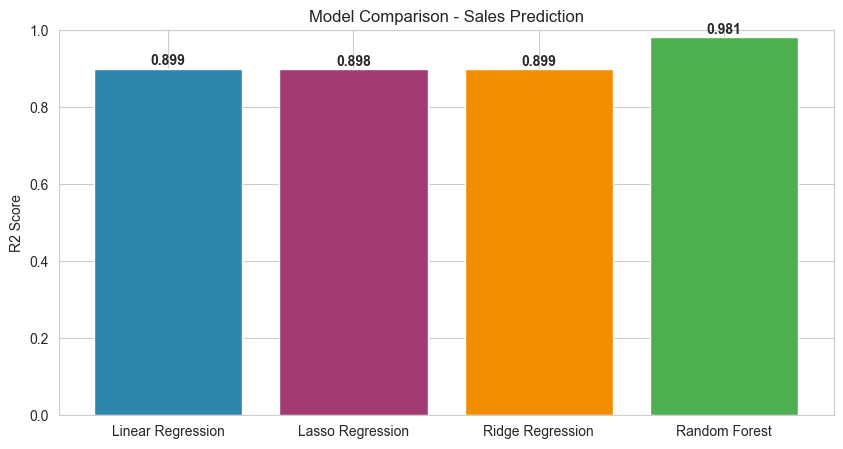

In [11]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df.index, results_df['R2 Score'], color=['#2E86AB', '#A23B72', '#F18F01', '#4CAF50'])
plt.ylabel('R2 Score')
plt.title('Model Comparison - Sales Prediction')
plt.ylim(0, 1)
for bar, val in zip(bars, results_df['R2 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')
plt.show()

---
## 5. Make a Prediction

In [12]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f'Best model: {best_model_name} (R2: {results_df.loc[best_model_name, "R2 Score"]:.4f})')

sample = X_test_scaled[0:1]
pred = best_model.predict(sample)
actual = y_test.iloc[0]
print(f'Predicted Sales: {pred[0]:.2f}')
print(f'Actual Sales:    {actual:.2f}')

Best model: Random Forest (R2: 0.9813)
Predicted Sales: 17.70
Actual Sales:    16.90
